# Lab 2: Point Operations and Color Space Transformations

## Theory

### Point Operations
Point operations are transformations applied independently to each pixel. The output intensity depends only on the input intensity.

#### Gamma Correction
Gamma correction is a non-linear transformation used to adjust brightness and contrast.

s = c * r^γ

where r is input intensity and γ controls brightness:
- γ < 1 → brightens image
- γ > 1 → darkens image

---

### Spatial Resolution
Spatial resolution refers to the number of pixels used to represent an image. Higher resolution means more detail. Reducing spatial resolution results in pixelation and loss of fine details due to undersampling.

---

### Intensity Resolution
Intensity resolution refers to the number of gray levels available. Lower intensity resolution results in quantization errors and visual artifacts such as false contouring.

---

### Color Spaces

#### RGB
Represents images using Red, Green, and Blue channels. It is primarily used for display.

#### YCrCb
Separates luminance (Y) from chrominance (Cr, Cb). This separation is useful in compression and video processing.

#### HSV
Separates Hue (color), Saturation (intensity of color), and Value (brightness). It is useful for color detection and segmentation.

# Experiment 1: Familiarization with OpenCV

## Problem
To perform basic image operations such as reading, displaying, resizing, and grayscale conversion.

## Theory
OpenCV is an open-source library used for image processing. It provides functions for reading, displaying, resizing, and converting images.

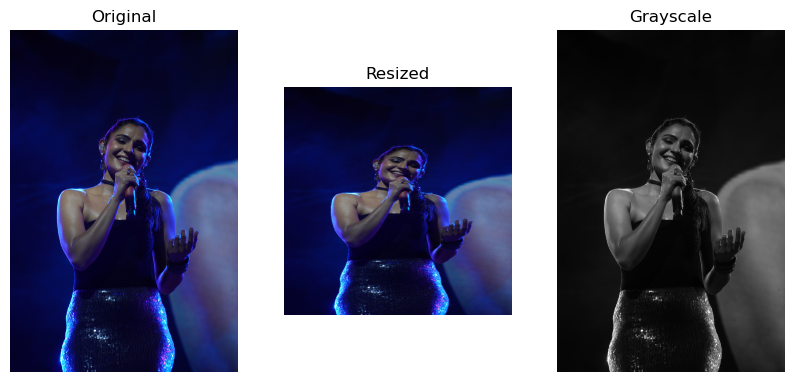

In [33]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('image.jpg')

# Convert BGR → RGB (VERY IMPORTANT)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

resized = cv2.resize(img_rgb, (500, 500))
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Display
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(resized)
plt.title("Resized")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.show()

# Experiment 2: Point Operations

## Problem
To apply brightness, contrast, and negative transformation to an image.

## Theory
Point operations modify pixel values independently. Brightness adds a constant, contrast multiplies pixel values, and negative inverts intensity.

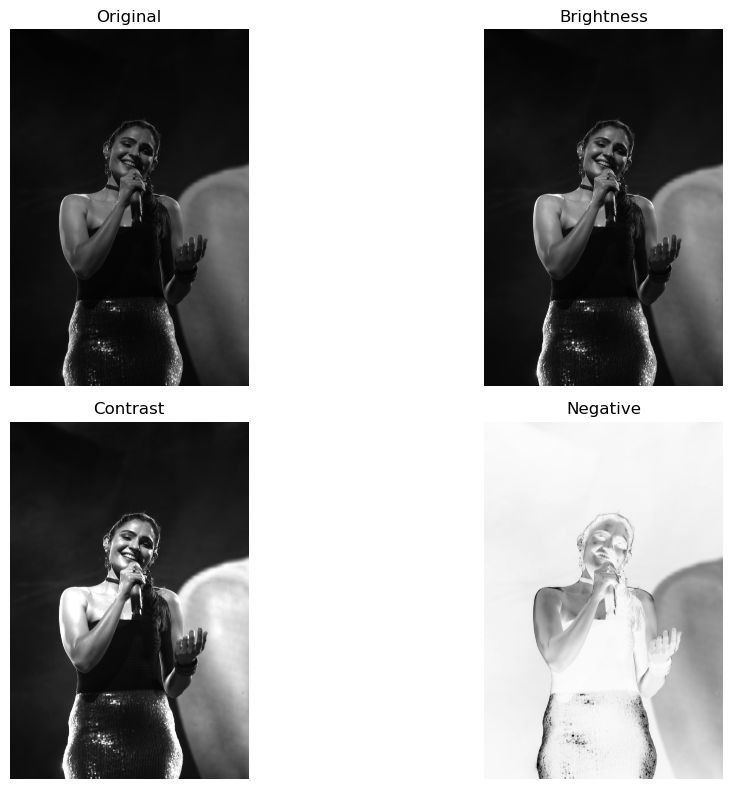

In [35]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

bright = cv2.convertScaleAbs(img, alpha=1, beta=50)
contrast = cv2.convertScaleAbs(img, alpha=2, beta=0)
negative = 255 - img

titles = ["Original", "Brightness", "Contrast", "Negative"]
images = [img, bright, contrast, negative]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Experiment 3: Spatial and Intensity Resolution

## Problem
To analyze the effect of spatial and intensity resolution on an image.

## Theory
Spatial resolution refers to image size (pixels), while intensity resolution refers to number of gray levels.

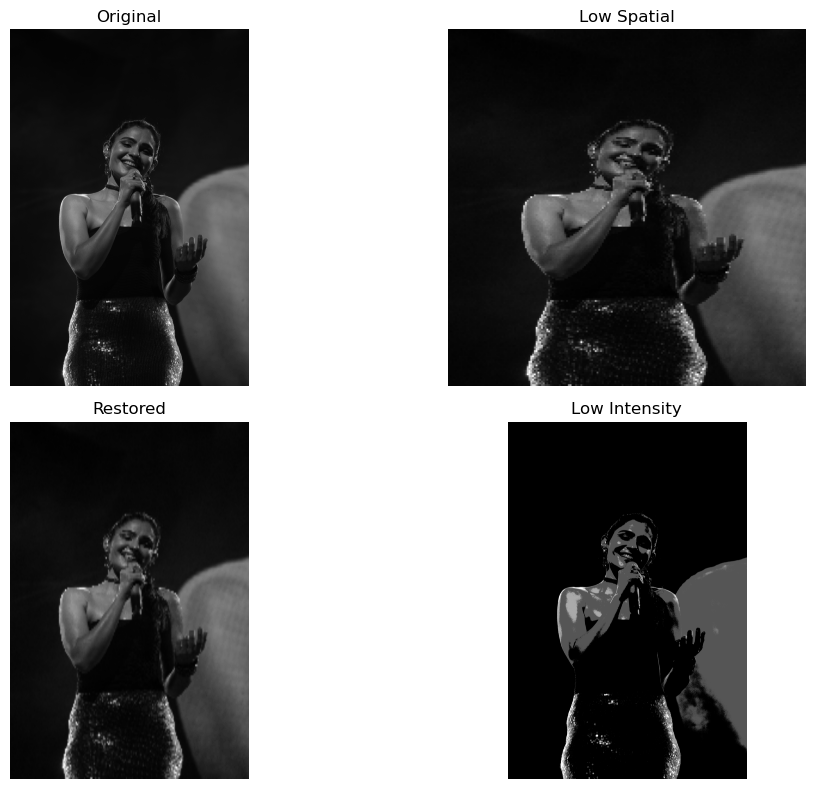

In [37]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Spatial resolution
small = cv2.resize(img, (200, 200))
large = cv2.resize(small, img.shape[::-1])

# Intensity resolution
levels = 4
quantized = (img // (256 // levels)) * (256 // levels)

titles = ["Original", "Low Spatial", "Restored", "Low Intensity"]
images = [img, small, large, quantized]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Experiment 4: RGB to YCrCb and HSV

## Problem
To convert an RGB image into YCrCb and HSV color spaces.

## Theory
Different color spaces represent image information differently. HSV separates color and intensity, while YCrCb separates luminance and chrominance.

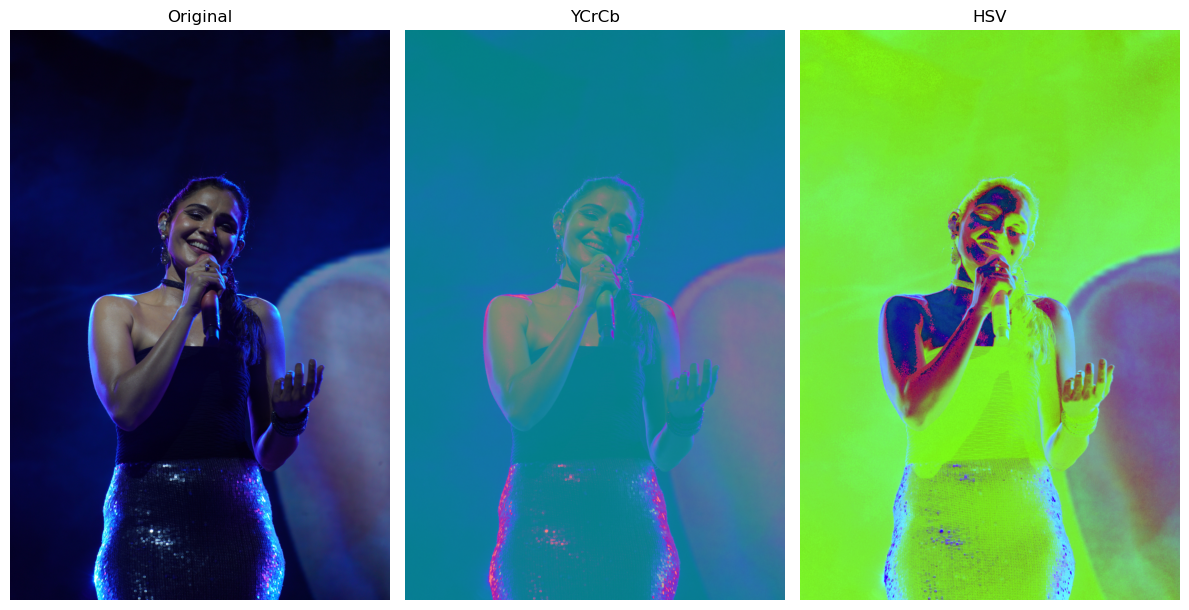

In [41]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(ycrcb)
plt.title("YCrCb")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis('off')

plt.tight_layout()
plt.show()